In [1]:
from RK.ide import ide_solve
from math   import exp, sin, cos, pi, log10
import numpy as np
import matplotlib.pyplot as plt

### Example 1 (only integral)

y_end =  148.41315925335257


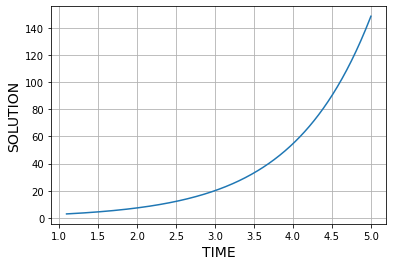

Convergence order: 3.9992668662883673


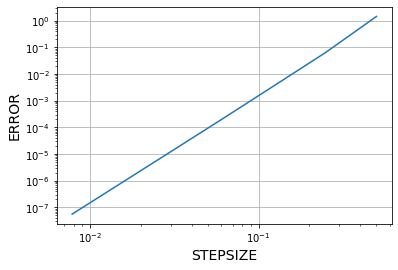

In [2]:
tspan      = [1.1, 5]
idefun     = lambda t,y,z,i: ((t-1)*exp(t*t)*i)/(exp(-1)*y-1)
K          = lambda t,s,y:   y*exp(-s*t)
delays     = lambda t,y:     t-1 # delays of z
delays_int = lambda t:       t-1 # delays of integrals
history    = lambda t:       exp(t)

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig1 = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

def fun1(t):
    return exp(t)
true_sol   = fun1(tspan[1])

nb = 1; n = 8
err = []; nsteps = []

for steppow in range(nb,n):
    stepsize = pow(2,-steppow)
    sol = ide_solve(idefun,delays,K,delays_int,history,tspan,stepsize)
    err.append(abs(true_sol - sol[1][-1]))
    nsteps.append(stepsize)

print("Convergence order:",(log10(err[-1])-log10(err[-2]))/(log10(pow(2,-n))-log10(pow(2,-n+1))))

fig2 = plt.subplots()
plt.plot(nsteps,err)
plt.xscale('log'); plt.yscale('log'); plt.xlabel("STEPSIZE", fontsize=14); plt.ylabel("ERROR", fontsize=14); plt.grid()
plt.show()

### Example 2 (integral+delays)

y_end =  -0.8390715237122065


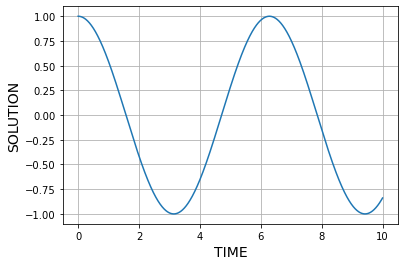

Convergence order: 3.9714186205724546


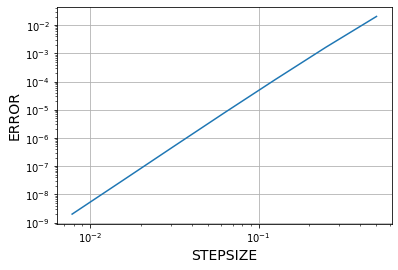

In [3]:
tspan      = [0, 10]
idefun     = lambda t,y,z,i: (1+exp(-pi/2))*y-exp(-pi/2)*z-2*exp(-2*t)*i
K          = lambda t,s,y:   y*exp(t+s)
delays     = lambda t,y:     t-pi/2 # delays of z
delays_int = lambda t:       t-pi/2 # delays of integrals
history    = lambda t:       cos(t)

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig1 = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

def fun1(t):
    return cos(t)
true_sol   = fun1(tspan[1])

nb = 1; n = 8
err = []; nsteps = []

for steppow in range(nb,n):
    stepsize = pow(2,-steppow)
    sol = ide_solve(idefun,delays,K,delays_int,history,tspan,stepsize)
    err.append(abs(true_sol - sol[1][-1]))
    nsteps.append(stepsize)

print("Convergence order:",(log10(err[-1])-log10(err[-2]))/(log10(pow(2,-n))-log10(pow(2,-n+1))))

fig2 = plt.subplots()
plt.plot(nsteps,err)
plt.xscale('log'); plt.yscale('log'); plt.xlabel("STEPSIZE", fontsize=14); plt.ylabel("ERROR", fontsize=14); plt.grid()
plt.show()

### Example 3 (integral+delays+overlapping)

y_end =  0.0067379469814580545


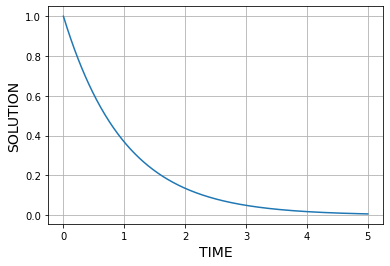

Convergence order: 3.990752239130475


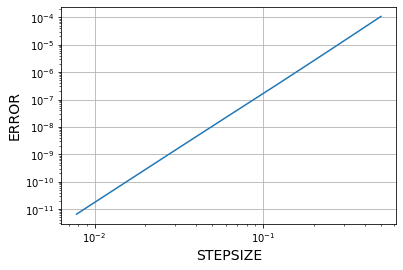

In [4]:
tspan      = [0, 5]
idefun     = lambda t,y,z,i: -y*y-t*exp(t*t)*pow(z,4)*i
K          = lambda t,s,y:   y*exp(s-s*t)
delays     = lambda t,y:     t/2 # delays of z
delays_int = lambda t:       t-1 # delays of integrals
history    = lambda t:       exp(-t)

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig1 = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

def fun1(t):
    return exp(-t)
true_sol   = fun1(tspan[1])

nb = 1; n = 8
err = []; nsteps = []

for steppow in range(nb,n):
    stepsize = pow(2,-steppow)
    sol = ide_solve(idefun,delays,K,delays_int,history,tspan,stepsize)
    err.append(abs(true_sol - sol[1][-1]))
    nsteps.append(stepsize)

print("Convergence order:",(log10(err[-1])-log10(err[-2]))/(log10(pow(2,-n))-log10(pow(2,-n+1))))

fig2 = plt.subplots()
plt.plot(nsteps,err)
plt.xscale('log'); plt.yscale('log'); plt.xlabel("STEPSIZE", fontsize=14); plt.ylabel("ERROR", fontsize=14); plt.grid()
plt.show()

### Example 4 (Yukihiko)

y_end =  -2.0422322798209653


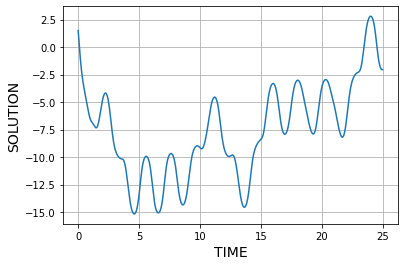

In [5]:
tspan      = [0, 25]
idefun     = lambda t,y,z,i: -15*i
K          = lambda t,s,y:   sin(y)
delays     = lambda t,y:     t-1 # delays of z
delays_int = lambda t:       t-1 # delays of integrals
history    = lambda t:       1.5

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

y_end =  -2.0422322798209653


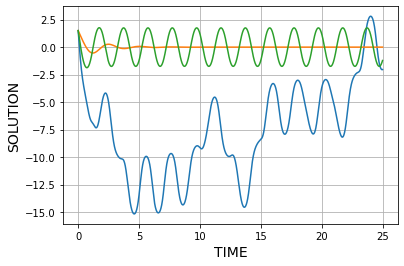

In [6]:
tspan      = [0, 25]
idefun     = lambda t,y,z,i: -15*i
K          = lambda t,s,y:   sin(y)
delays     = lambda t,y:     t-1 # delays of z
delays_int = lambda t:       t-1 # delays of integrals
history    = lambda t:       1.5

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig = plt.subplots()
plt.plot(sol[0], sol[1])

idefun     = lambda t,y,z,i: -2.5*i
sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)
plt.plot(sol[0], sol[1])

idefun     = lambda t,y,z,i: -7.5*i
sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)
plt.plot(sol[0], sol[1])

plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()